### Inspección visual

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
def graficar_outliers(serie, fechas, outliers = None):
    ax = serie.plot(alpha = 0.7)

    serie.loc[fechas].plot(ax = ax, style = 'bo')

    if outliers is not None:
        outliers.plot(ax = ax, style = 'rx')
        plt.legend(['Serie de tiempo', 'Outliers conocidos', 'Outliers desconocidos'])
    else:
        plt.legend(['Serie de tiempo', 'Outliers conocidos'])
    
    plt.xlabel('Fecha')
    plt.ylabel('# pasajeros')


In [29]:
ind = pd.date_range(start= pd.to_datetime('2024-01-01'), end = pd.to_datetime('2024-01-08'))
obs = [23, 17, 6, 15, 80, 12, 19, 21]
df = pd.DataFrame(obs,
                index=ind, 
                columns=['Valores'])
print(df)

            Valores
2024-01-01       23
2024-01-02       17
2024-01-03        6
2024-01-04       15
2024-01-05       80
2024-01-06       12
2024-01-07       19
2024-01-08       21


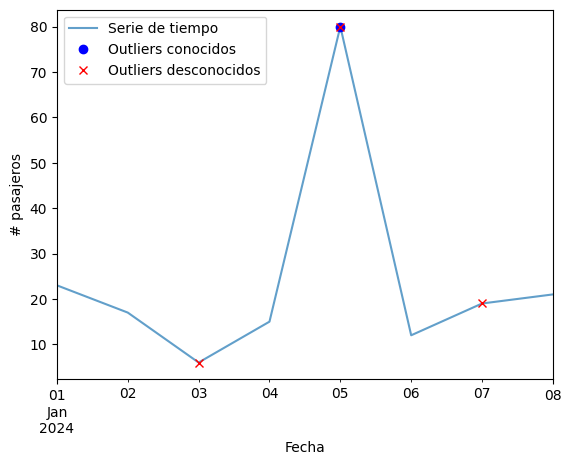

In [30]:
# Outliers conocidos
fechas = ['2024-01-05']
outliers = df.iloc[[2, 4, 6], :]
graficar_outliers(df, fechas, outliers)

In [31]:
taxis = pd.read_csv('datos/taxis_ny.csv',
                    parse_dates=['tiempo'],
                    index_col='tiempo')
taxis

,obs
tiempo,
2014-07-01 00:00:00,10844
2014-07-01 00:30:00,8127
2014-07-01 01:00:00,6210
2014-07-01 01:30:00,4656
2014-07-01 02:00:00,3820
...,...
2015-01-31 21:30:00,24670
2015-01-31 22:00:00,25721
2015-01-31 22:30:00,27309


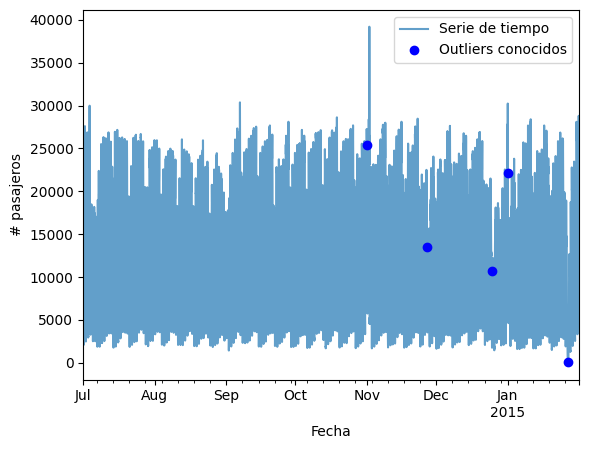

In [32]:
fechas = [
    '2014-11-01',
    '2014-11-27',
    '2014-12-25',
    '2015-01-01',
    '2015-01-27',
]
graficar_outliers(taxis, fechas)

### Detección con gráficos simples

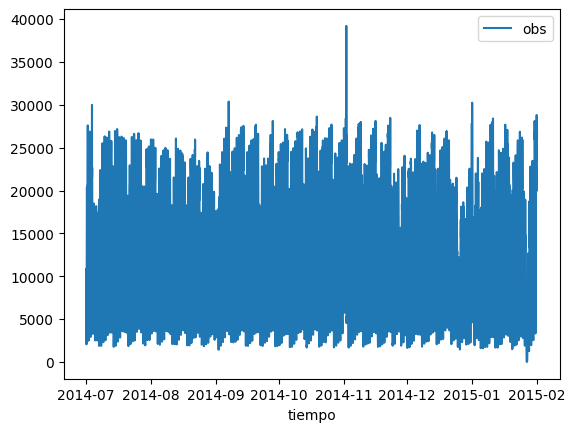

In [33]:
import seaborn as sns
ax = sns.lineplot(taxis)

Aplicación de un remuestreo de la serie con frecuencia de 1 día

10320
215


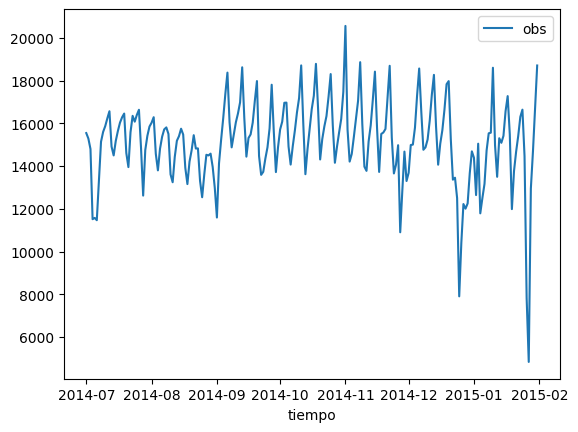

In [34]:
tx_diario = taxis.resample('D').mean()
print(len(taxis))
print(len(tx_diario))
ax = sns.lineplot(tx_diario)

### Detección con gráficos interactivos

In [35]:
import plotly.express as px

fig = px.line(tx_diario)
fig.show()

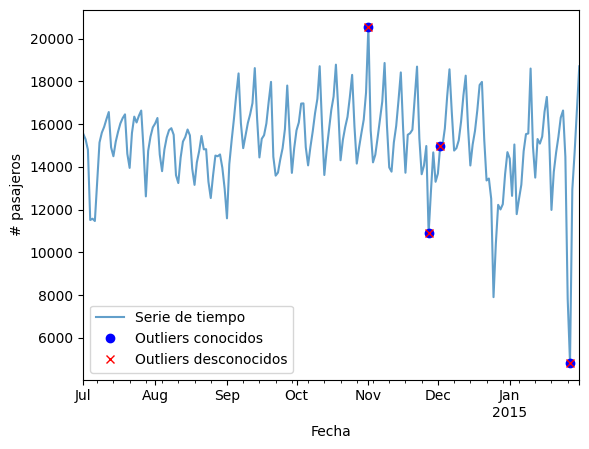

In [36]:
fechas_outliers = ['2014-11-01', '2014-11-27', '2014-12-2', '2015-01-27']
outliers = tx_diario.loc[fechas_outliers]

graficar_outliers(tx_diario, fechas=fechas_outliers, outliers=outliers)

### Detección usando box-plots

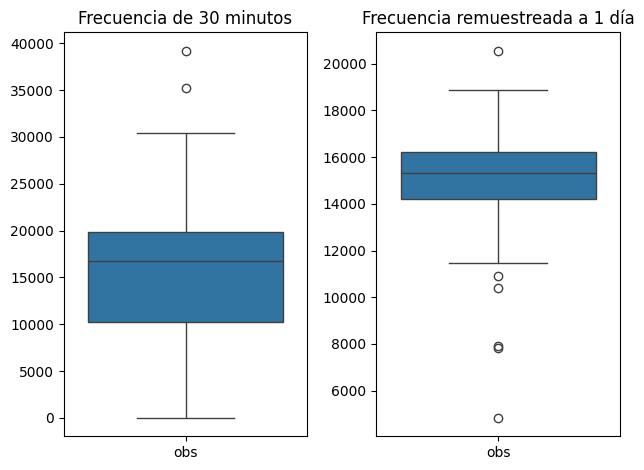

In [37]:
fig, ax = plt.subplots(1, 2)

sns.boxplot(taxis, ax = ax[0])
ax[0].set_title('Frecuencia de 30 minutos')

sns.boxplot(tx_diario, ax = ax[1])
ax[1].set_title('Frecuencia remuestreada a 1 día')

fig.tight_layout()

In [38]:
w_inf = 11800
w_sup = 19000

mask = (tx_diario['obs']<= w_inf) | (tx_diario['obs']>= w_sup)
outliers_box = tx_diario[mask]
outliers_box

,obs
tiempo,
2014-07-04,11511.770833
2014-07-05,11572.291667
2014-07-06,11464.270833
2014-09-01,11589.875000
2014-11-01,20553.500000
2014-11-27,10899.666667
2014-12-25,7902.125000
2014-12-26,10397.958333
2015-01-04,11785.604167


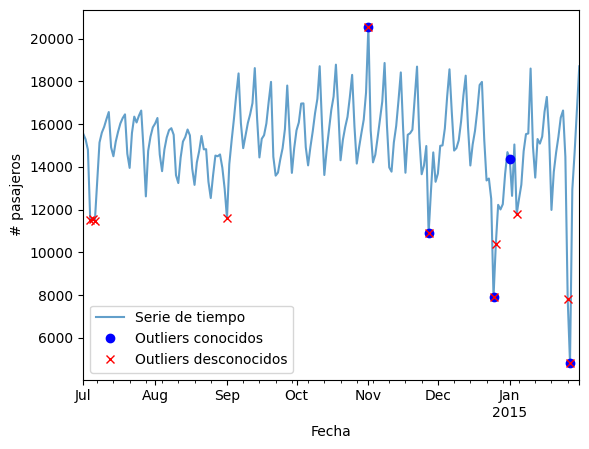

In [40]:
graficar_outliers(tx_diario, fechas=fechas, outliers=outliers_box)